## Building models (many to many)

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### loading the libraries
import pandas as pd
import numpy as np
import joblib

In [3]:
### importing the tensorflow libraries
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional

In [4]:
### setting up the system path
import sys
sys.path.append('../')

In [5]:
### importing the libraries
from src.graphs.graphs_metrices import metrices, plot_predictions, plot_graphs_post_scaling
from src.future_pred.future_pred import gen_future_dates, gen_future_prices, gen_future_price_graphs
from src.build_sequences.build_sequences import build_sequences

In [6]:
### loading the data
df = pd.read_csv('../stocks/apple-18-2.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19 00:00:00+00:00,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22 00:00:00+00:00,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23 00:00:00+00:00,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24 00:00:00+00:00,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25 00:00:00+00:00,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [7]:
### changing the data type of the 'date'
df['date'] = df['date'].astype(dtype = 'date64[pyarrow]')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [8]:
### df_copy for the scaler comparison
df_copy = df.copy()
df_copy.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [9]:
### features to target
features_to_target = ['close', 'high', 'low', 'open', 'volume']
features_to_target

['close', 'high', 'low', 'open', 'volume']

In [10]:
### scaling the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df[features_to_target] = scaler.fit_transform(df[features_to_target])

feature : close


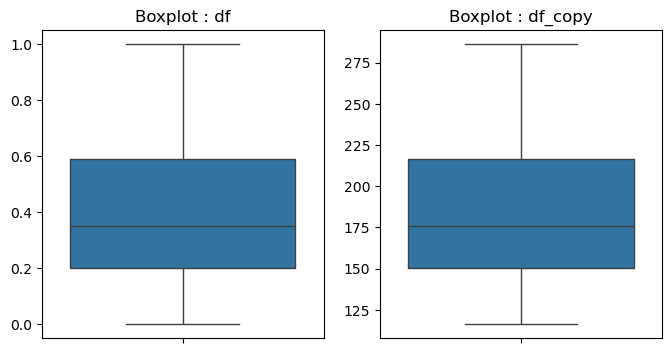

feature : high


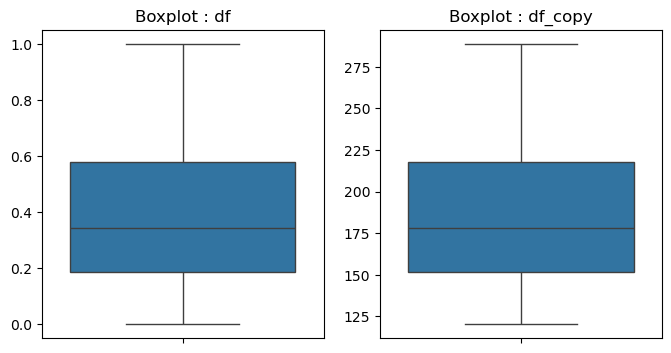

feature : low


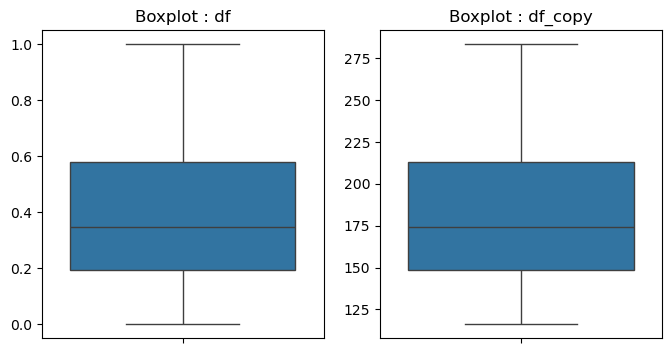

feature : open


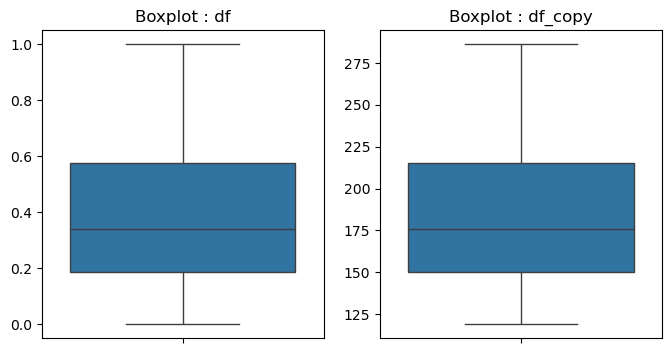

feature : volume


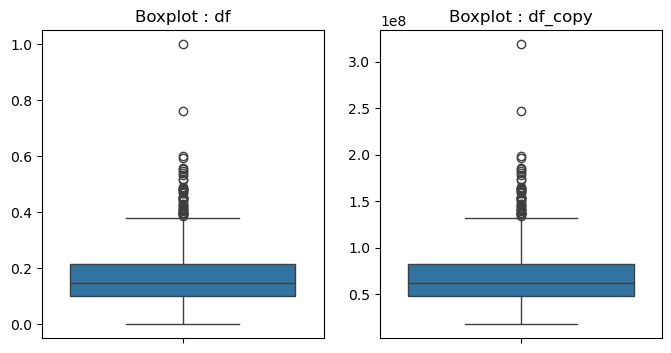

In [11]:
### plotting the scaled vs non scaled data
plot_graphs_post_scaling(df, df_copy, cols = features_to_target)

In [ ]:
### saving the scaled data
# df.to_csv('../stocks/apple_scaled.csv', index = False)

In [12]:
### loading again to check the data
# df = pd.read_csv('../stocks/apple_scaled.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,0.079550,0.061271,0.075349,0.067057,0.231933,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,0.056763,0.055386,0.056197,0.053718,0.282530,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,0.055938,0.037493,0.013047,0.028295,0.466678,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,0.052935,0.030656,0.036028,0.035353,0.309637,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,0.027263,0.035998,0.025914,0.033798,0.421773,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


### 90 days window

In [33]:
### making the sequences
X_train_90, X_test_90, y_train_90, y_test_90 = build_sequences(df, days = 90, features_to_target = features_to_target)

(1004, 90, 5) :: (1004, 5) 
(161, 90, 5) :: (161, 5)


In [34]:
### making the sequence model
model_90 = Sequential([
    LSTM(50, return_sequences = True, input_shape = (90, 5)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(5, activation = 'linear')
])
model_90.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
### checking the model summary
model_90.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 90, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 90, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,005 (519.55 KB)

 Trainable params: 133,005 (519.55 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
### training the model
model_90.fit(X_train_90, y_train_90, batch_size = 32, epochs = 30, verbose = 1)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0498 - mse: 0.0498
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0065 - mse: 0.0065
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0056 - mse: 0.0056
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0053 - mse: 0.0053
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0052 - mse: 0.0052
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0050 - mse: 0.0050
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0045 - mse: 0.0045
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0045 - mse: 0.0045
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0044 - mse: 0.0044
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0044 - mse: 0.0044
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0044 - mse: 0.0044
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0041 - mse: 0.0041
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━

In [37]:
### y_pred_90
y_pred_90 = model_90.predict(X_test_90)
y_pred_90

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step


array([[0.5255637 , 0.51845944, 0.5271177 , 0.5265861 , 0.14478162],
       [0.5252709 , 0.5188051 , 0.5270337 , 0.52683705, 0.1537953 ],
       [0.53097194, 0.5252233 , 0.5330826 , 0.53320575, 0.16089904],
       [0.5428989 , 0.53749794, 0.54535806, 0.5459121 , 0.16176453],
       [0.5612057 , 0.5556624 , 0.56382525, 0.56480193, 0.15359181],
       [0.574788  , 0.56912404, 0.5775467 , 0.5788137 , 0.14719415],
       [0.5823295 , 0.5765714 , 0.58522797, 0.5864044 , 0.14158323],
       [0.5845177 , 0.57889223, 0.5873792 , 0.58879197, 0.13884164],
       [0.5865785 , 0.58054084, 0.5892018 , 0.5908254 , 0.13517931],
       [0.5865891 , 0.5805176 , 0.5895089 , 0.59079206, 0.13216177],
       [0.584163  , 0.5778526 , 0.5871614 , 0.58842295, 0.12933592],
       [0.581087  , 0.57458645, 0.58429956, 0.58529645, 0.12831192],
       [0.5777768 , 0.57133675, 0.5810945 , 0.58232653, 0.12946892],
       [0.57495   , 0.5687635 , 0.57811046, 0.57993186, 0.13232005],
       [0.57296044, 0.5668806 , 0.

In [38]:
### checking the y_pred_90 shape
y_pred_90.shape

(161, 5)

In [39]:
### using the inverse scaler
y_test_90 = scaler.inverse_transform(y_test_90)
y_pred_90 = scaler.inverse_transform(y_pred_90)

feature : close
MAE : 4.8636642323369585
MSE : 39.99984087517756
RMSE : 6.324542740402468


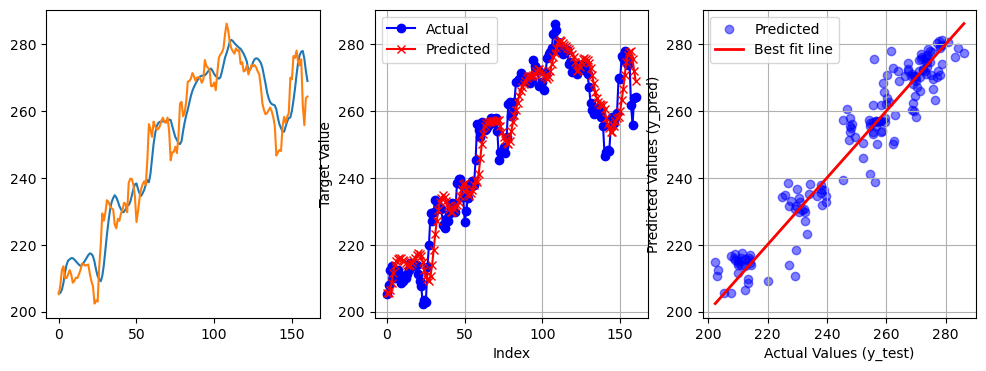

feature : high
MAE : 4.585176506089869
MSE : 33.1161144905948
RMSE : 5.754660241108488


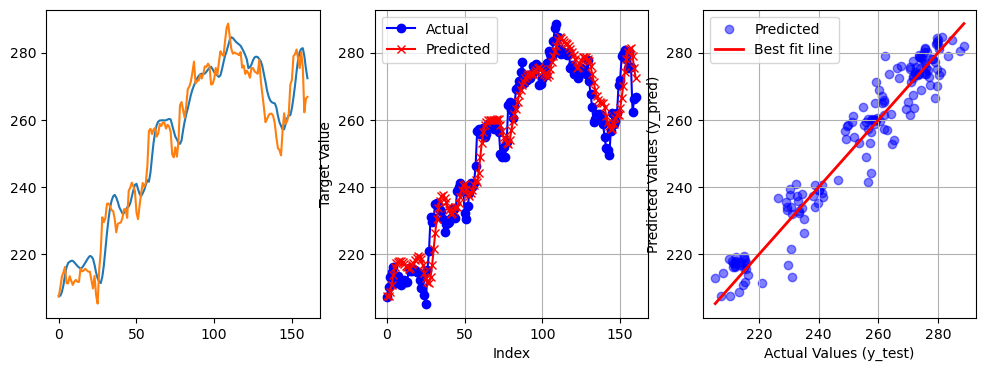

feature : low
MAE : 4.426097221952641
MSE : 32.89348133942663
RMSE : 5.735283893533661


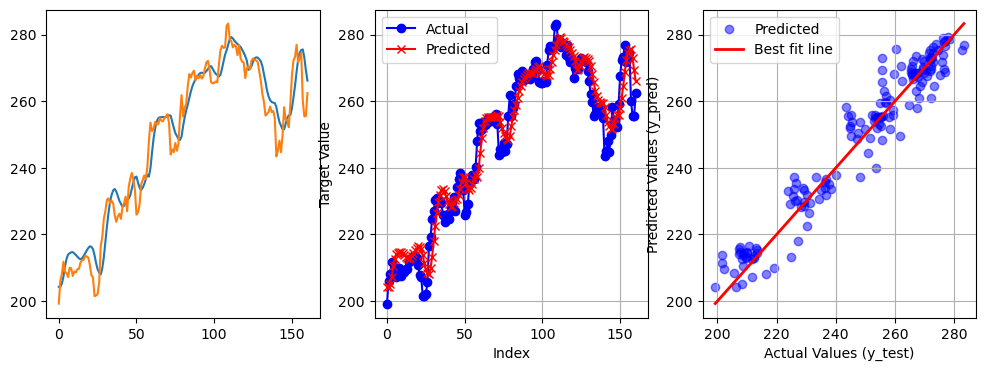

feature : open
MAE : 4.946349563124759
MSE : 35.041448632505016
RMSE : 5.919581795406245


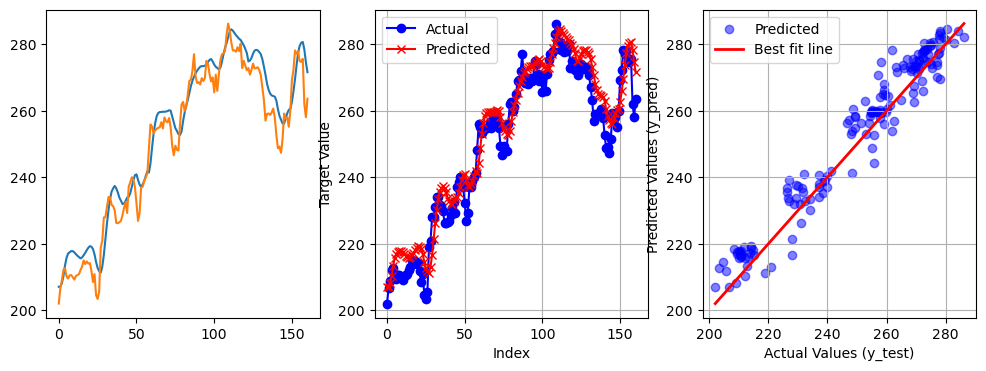

feature : volume
MAE : 15823417.608695652
MSE : 428777149582041.2
RMSE : 20706934.818607055


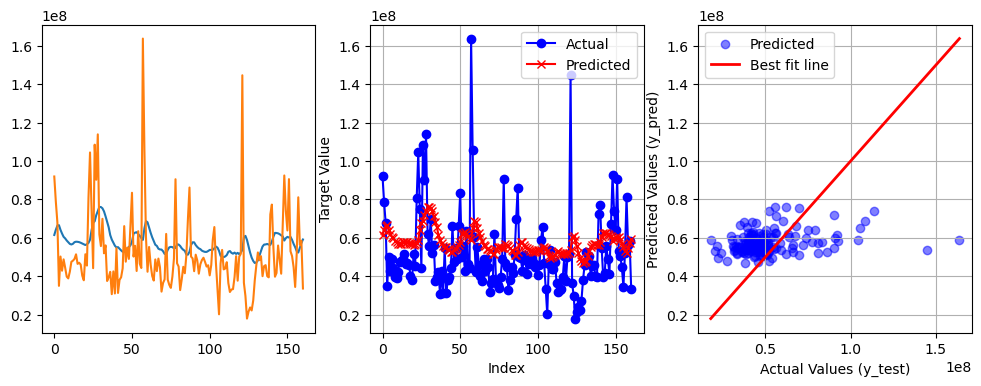

In [40]:
### metrices and graphs
for i in range (0, 5) : 
    print(f"feature : {features_to_target[i]}")
    metrices(y_test_90[:, i], y_pred_90[:, i])
    plot_predictions(y_test_90[:, i], y_pred_90[:, i])

### 120 days window

In [41]:
### making the sequence
X_train_120, X_test_120, y_train_120, y_test_120 = build_sequences(df, 120, features_to_target)

(1004, 120, 5) :: (1004, 5) 
(131, 120, 5) :: (131, 5)


In [42]:
### making the sequential model
model_120 = Sequential([
    LSTM(50, return_sequences = True, input_shape = (120, 5)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(5, activation = 'linear')
])
model_120.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
### checking the model summary
model_120.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 120, 50)        │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 120, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,005 (519.55 KB)

 Trainable params: 133,005 (519.55 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
### training the moodel
model_120.fit(X_train_120, y_train_120, epochs = 30, batch_size = 32, verbose = 1)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0439 - mse: 0.0439
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0075 - mse: 0.0075
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0060 - mse: 0.0060
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0057 - mse: 0.0057
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0058 - mse: 0.0058
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0049 - mse: 0.0049
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0047 - mse: 0.0047
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0045 - mse: 0.0045
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0041 - mse: 0.0041
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0042 - mse: 0.0042
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0044 - mse: 0.0044
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0041 - mse: 0.0041
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━

In [45]:
### y_pred_120
y_pred_120 = model_120.predict(X_test_120)
y_pred_120

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


array([[0.58209556, 0.5787844 , 0.57495403, 0.57564163, 0.15016341],
       [0.610442  , 0.6074036 , 0.60413945, 0.60533047, 0.14012563],
       [0.6343014 , 0.6317173 , 0.6289081 , 0.63001406, 0.13235444],
       [0.65412456, 0.6516245 , 0.64960647, 0.6500119 , 0.12444979],
       [0.6659682 , 0.6634618 , 0.66226125, 0.66137373, 0.11923004],
       [0.6722971 , 0.66970015, 0.66965497, 0.6671709 , 0.11258709],
       [0.6731303 , 0.67039657, 0.6712875 , 0.6673478 , 0.10691376],
       [0.6674516 , 0.6644938 , 0.66632825, 0.6607698 , 0.1037951 ],
       [0.6587582 , 0.6550664 , 0.65774757, 0.65065956, 0.10080008],
       [0.64949894, 0.64543307, 0.6488133 , 0.6406456 , 0.09956891],
       [0.6432498 , 0.63870454, 0.64287484, 0.63400483, 0.09687576],
       [0.6370114 , 0.63219965, 0.6363847 , 0.62734365, 0.09793063],
       [0.6368227 , 0.6317429 , 0.63667536, 0.62744236, 0.09500439],
       [0.63958526, 0.63442093, 0.64048004, 0.6307523 , 0.09216333],
       [0.6438049 , 0.63853115, 0.

In [46]:
### checking the y_pred shape
y_pred_120.shape

(131, 5)

In [47]:
### inverse scaling
y_pred_120 = scaler.inverse_transform(y_pred_120)
y_test_120 = scaler.inverse_transform(y_test_120)

feature : close
MAE : 7.349004800811068
MSE : 76.75931805912339
RMSE : 8.761239527551075


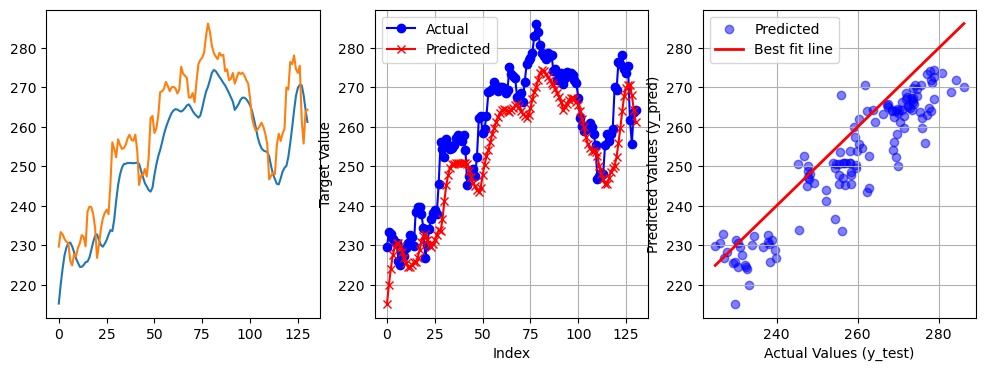

feature : high
MAE : 6.629567313111284
MSE : 65.52955070065323
RMSE : 8.095032470636127


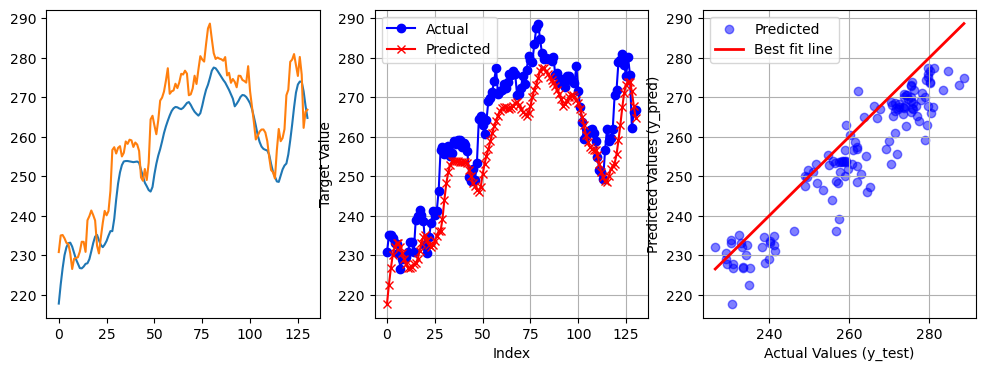

feature : low
MAE : 6.895833011912571
MSE : 66.12815241316436
RMSE : 8.131921815485216


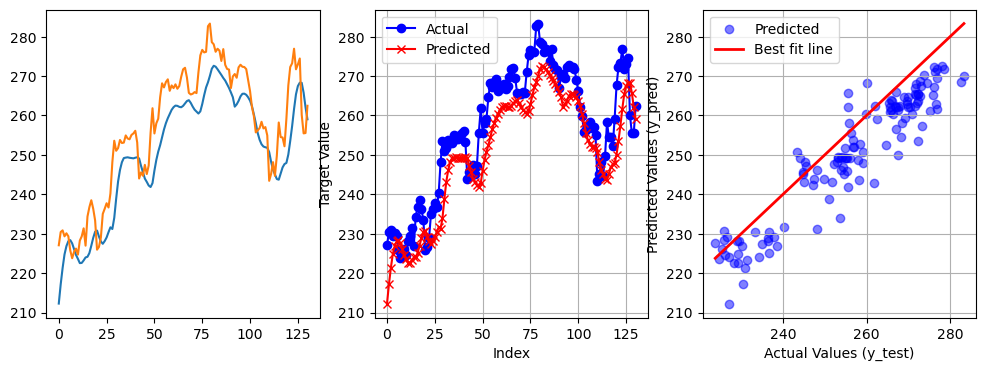

feature : open
MAE : 7.007588454384839
MSE : 66.96191975260284
RMSE : 8.183026319926073


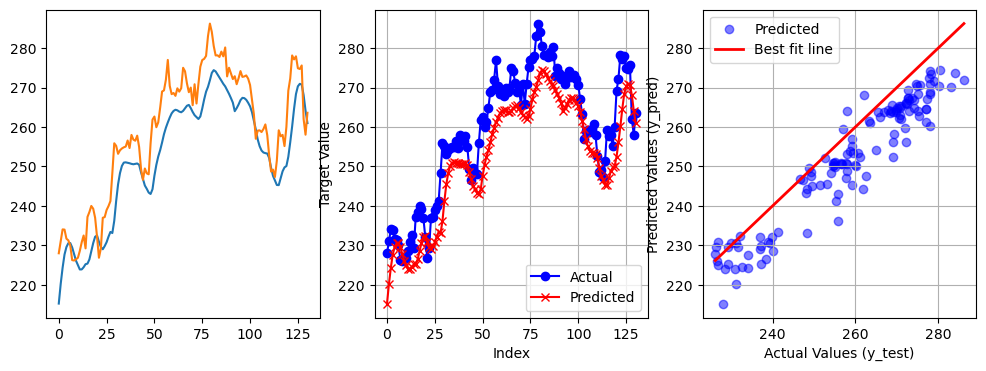

feature : volume
MAE : 11942370.38167939
MSE : 391127725077279.25
RMSE : 19776949.336975086


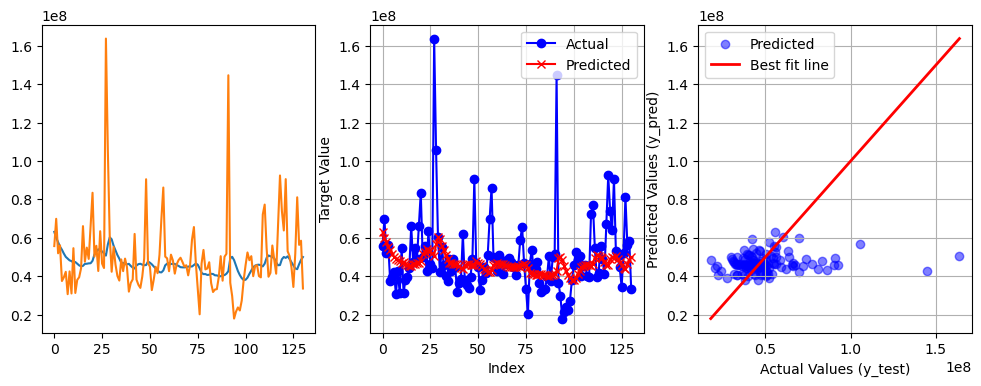

In [48]:
### metrices and graphs
for i in range (0, 5) : 
    print(f"feature : {features_to_target[i]}")
    metrices(y_test_120[:, i], y_pred_120[:, i])
    plot_predictions(y_test_120[:, i], y_pred_120[:, i])

### saving out the things

In [51]:
### saving the both models and the scaler
joblib.dump(model_90, '../saved_models_scalers/model_90.pkl')
joblib.dump(model_120, '../saved_models_scalers/model_120.pkl')
joblib.dump(scaler, '../saved_models_scalers/scaler.pkl')

['../saved_models_scalers/scaler.pkl']